# 📄 Report Generation Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/report-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/report-agent/demo.ipynb)

> **Monthly reports take 2 days of copy-paste.** This agent turns a table of metrics into a ready-to-send report in seconds.

**The idea:** instead of one prompt doing everything, a small **team of role-specialized agents** each own one section of the report — a *Chief of Staff* writes the exec summary, a *Data Analyst* builds the metrics table, a *Growth Lead* pulls highlights, a *Risk Officer* flags watch items, and a *Strategy Lead* proposes next steps. A coordinator assembles their drafts into a templated report.

**This notebook covers:**
1. The data model — `Metric` with trend + "higher is better" logic
2. The section agents — each a distinct lens over the same data
3. Running the multi-agent report builder
4. A chart of metric movement
5. Try your own metrics


## Step 1 — The data model

Each metric knows its current value, prior value, unit, and whether *up* is good. `Churn Rate` and `Support Tickets` are inverted — a decrease is a win. This one flag is what lets the agents reason correctly about wins vs. risks.


In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Callable, List, Optional


@dataclass
class Metric:
    name: str
    value: float
    prior: float
    unit: str = ""
    higher_is_better: bool = True

    @property
    def delta(self) -> float:
        return self.value - self.prior

    @property
    def pct_change(self) -> Optional[float]:
        if self.prior == 0:
            return None
        return (self.value - self.prior) / abs(self.prior) * 100.0

    @property
    def improved(self) -> bool:
        return self.delta >= 0 if self.higher_is_better else self.delta <= 0

    def fmt(self, v: float) -> str:
        if self.unit == "$":
            return f"${v:,.0f}"
        if self.unit == "%":
            return f"{v:.1f}%"
        return f"{v:,.0f}{self.unit}"

    def trend_arrow(self) -> str:
        return "→" if self.delta == 0 else ("↑" if self.delta > 0 else "↓")


metrics = [
    Metric("Revenue", 128_400, 112_000, unit="$"),
    Metric("Active Users", 8_920, 8_100),
    Metric("Churn Rate", 4.8, 3.9, unit="%", higher_is_better=False),
    Metric("NPS", 47, 44),
    Metric("Support Tickets", 610, 720, higher_is_better=False),
]

for m in metrics:
    tag = "win" if m.improved else "RISK"
    print(f"{m.trend_arrow()} {m.name:16} {m.fmt(m.value):>10}  ({m.pct_change:+.1f}%)  -> {tag}")


↑ Revenue            $128,400  (+14.6%)  -> win
↑ Active Users          8,920  (+10.1%)  -> win
↑ Churn Rate             4.8%  (+23.1%)  -> RISK
↑ NPS                      47  (+6.8%)  -> win
↓ Support Tickets         610  (-15.3%)  -> win


## Step 2 — The section agents

Each agent is just a `(name, role, generator)` triple. The generator reads the shared context and returns markdown for its section. This is the multi-agent pattern in miniature: independent specialists, one shared input, a fixed assembly order.


In [2]:
@dataclass
class ReportContext:
    title: str
    period: str
    metrics: List[Metric]
    notes: str = ""


def _pct(m: Metric) -> str:
    return "n/a" if m.pct_change is None else f"{m.pct_change:+.1f}%"


def exec_summary(ctx: ReportContext) -> str:
    improved = [m for m in ctx.metrics if m.improved]
    declined = [m for m in ctx.metrics if not m.improved]
    lead = ctx.metrics[0]
    s = f"In {ctx.period}, {len(improved)} of {len(ctx.metrics)} key metrics moved in the right direction. "
    s += f"{lead.name} landed at {lead.fmt(lead.value)} ({_pct(lead)} vs. prior period). "
    if declined:
        s += "Watch items: " + ", ".join(m.name for m in declined) + "."
    return s


def metrics_table(ctx: ReportContext) -> str:
    rows = ["| Metric | Current | Prior | Change | Trend |", "|---|---|---|---|---|"]
    for m in ctx.metrics:
        rows.append(f"| {m.name} | {m.fmt(m.value)} | {m.fmt(m.prior)} | {_pct(m)} | {m.trend_arrow()} |")
    return "\n".join(rows)


def highlights(ctx: ReportContext) -> str:
    wins = sorted((m for m in ctx.metrics if m.improved), key=lambda m: abs(m.pct_change or 0), reverse=True)
    return "\n".join(f"- {m.name} {m.trend_arrow()} {m.fmt(m.value)} ({_pct(m)})" for m in wins) or "No wins this period."


def risks(ctx: ReportContext) -> str:
    losses = sorted((m for m in ctx.metrics if not m.improved), key=lambda m: abs(m.pct_change or 0), reverse=True)
    return "\n".join(f"- **{m.name}** {m.trend_arrow()} {m.fmt(m.value)} ({_pct(m)}) - needs attention." for m in losses) or "No material risks."


def next_steps(ctx: ReportContext) -> str:
    losses = [m for m in ctx.metrics if not m.improved]
    steps = [f"- Assign an owner to investigate the {m.name} decline." for m in losses]
    if not steps:
        steps = ["- Maintain current playbook; set a stretch target for the top metric."]
    if ctx.notes:
        steps.append(f"- Follow up on context: {ctx.notes}")
    return "\n".join(steps)


AGENTS = [
    ("Executive Summary", "Chief of Staff", exec_summary),
    ("Key Metrics", "Data Analyst", metrics_table),
    ("Highlights", "Growth Lead", highlights),
    ("Risks & Watch Items", "Risk Officer", risks),
    ("Next Steps", "Strategy Lead", next_steps),
]
print(f"{len(AGENTS)} section agents registered:")
for name, role, _ in AGENTS:
    print(f"  - {role:14} -> {name}")


5 section agents registered:
  - Chief of Staff -> Executive Summary
  - Data Analyst   -> Key Metrics
  - Growth Lead    -> Highlights
  - Risk Officer   -> Risks & Watch Items
  - Strategy Lead  -> Next Steps


## Step 3 — Run the multi-agent report builder

The coordinator runs each agent in order and assembles the sections under a title, period, and table of contents. (In the full app, an optional Claude pass polishes each draft when `ANTHROPIC_API_KEY` is set — here we use the deterministic rule-based prose so it runs anywhere.)


In [3]:
def build_report(ctx: ReportContext) -> str:
    out = [f"# {ctx.title}", f"*{ctx.period}*", "", "## Contents"]
    for name, _, _ in AGENTS:
        out.append(f"- {name}")
    out.append("")
    for name, role, gen in AGENTS:
        out.append(f"## {name}")
        out.append(f"*Prepared by: {role}*")
        out.append("")
        out.append(gen(ctx))
        out.append("")
    return "\n".join(out).strip()


ctx = ReportContext(
    title="Monthly Business Review",
    period="June 2026",
    metrics=metrics,
    notes="New onboarding flow shipped mid-month.",
)
report_md = build_report(ctx)
print(report_md)


# Monthly Business Review
*June 2026*

## Contents
- Executive Summary
- Key Metrics
- Highlights
- Risks & Watch Items
- Next Steps

## Executive Summary
*Prepared by: Chief of Staff*

In June 2026, 4 of 5 key metrics moved in the right direction. Revenue landed at $128,400 (+14.6% vs. prior period). Watch items: Churn Rate.

## Key Metrics
*Prepared by: Data Analyst*

| Metric | Current | Prior | Change | Trend |
|---|---|---|---|---|
| Revenue | $128,400 | $112,000 | +14.6% | ↑ |
| Active Users | 8,920 | 8,100 | +10.1% | ↑ |
| Churn Rate | 4.8% | 3.9% | +23.1% | ↑ |
| NPS | 47 | 44 | +6.8% | ↑ |
| Support Tickets | 610 | 720 | -15.3% | ↓ |

## Highlights
*Prepared by: Growth Lead*

- Support Tickets ↓ 610 (-15.3%)
- Revenue ↑ $128,400 (+14.6%)
- Active Users ↑ 8,920 (+10.1%)
- NPS ↑ 47 (+6.8%)

## Risks & Watch Items
*Prepared by: Risk Officer*

- **Churn Rate** ↑ 4.8% (+23.1%) - needs attention.

## Next Steps
*Prepared by: Strategy Lead*

- Assign an owner to investigate the Churn

## Step 4 — Visualize the metric movement

A quick diverging bar chart of period-over-period % change, colored by whether each move was a **win** (green) or a **risk** (red) — using each metric's `higher_is_better` flag, not just the raw direction.


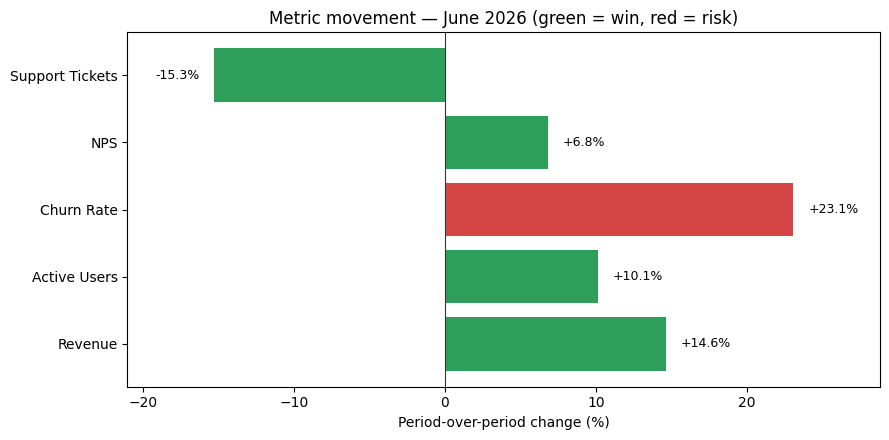

In [4]:
import matplotlib.pyplot as plt

names = [m.name for m in metrics]
changes = [m.pct_change for m in metrics]
colors = ["#2e9e5b" if m.improved else "#d64545" for m in metrics]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(names, changes, color=colors)
ax.axvline(0, color="#333", linewidth=0.8)
ax.set_xlabel("Period-over-period change (%)")
ax.set_title("Metric movement — June 2026 (green = win, red = risk)")
for bar, ch in zip(bars, changes):
    ax.text(ch + (1 if ch >= 0 else -1), bar.get_y() + bar.get_height() / 2,
            f"{ch:+.1f}%", va="center", ha="left" if ch >= 0 else "right", fontsize=9)
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig("report_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

| Section | Agent (role) | Auto-derived from |
|---|---|---|
| Executive Summary | Chief of Staff | win/loss count + lead metric |
| Key Metrics | Data Analyst | full metrics table |
| Highlights | Growth Lead | improved metrics, ranked |
| Risks & Watch Items | Risk Officer | declined metrics, ranked |
| Next Steps | Strategy Lead | one action per declining metric |

Two days of copy-paste becomes one function call — and the "higher is better" flag means an increase in churn is correctly flagged as a **risk**, not a highlight.


## Try your own metrics

Edit the list below and re-run — swap in your own KPIs, set `higher_is_better=False` for anything where down is good (cost, latency, churn), and regenerate the whole report.


In [5]:
# my_metrics = [
#     Metric("MRR", 54_000, 49_000, unit="$"),
#     Metric("Trial-to-Paid", 22.0, 19.5, unit="%"),
#     Metric("Avg Response Time", 340, 410, unit="ms", higher_is_better=False),
# ]
# my_ctx = ReportContext(title="My Product Review", period="Q3 2026", metrics=my_metrics)
# print(build_report(my_ctx))


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 47, AI Agent Workshop.

For the interactive Streamlit version (editable metrics table + Claude-polished prose + one-click `report.md` download):
```bash
pip install -r requirements.txt
streamlit run app.py
```
